# Dataset inspection: high-motion vs low-motion, masked vs unmasked (chunk5)

Focuses on `cyclegans_chunk5_dataset` (5-timepoint chunks) only, comparing two things at once:

1. **Domain**: a high-motion chunk (`A_corrupted`) vs a low-motion chunk (`B_motion_free`).
2. **Masking**: each chunk's actual dataset version (brain-masked) vs the same volumes pulled
   from the pre-masking pipeline stage (`normalized_to_common_space`, i.e.
   `..._bold_mcf_corrected_flirt.nii.gz`, same motion-correction/registration, mask not yet applied).

Both example chunks are from the same subject (`ICC103A`), different runs of the `videos` task --
purely so the two conditions are easy to compare side by side. CycleGAN training itself stays
unpaired (A_corrupted and B_motion_free are never assumed to correspond 1:1).

In [2]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_ROOT = Path("/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/faizan_motion_correction_dataset")
DERIVATIVES_ROOT = Path("/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives")

# High-motion (A_corrupted) chunk: mean FD 3.21, max FD 8.26, 4/5 volumes above the FD threshold.
HIGH_MOTION_MASKED_PATH = DATASET_ROOT / "cyclegans_chunk5_dataset/train/A_corrupted/sub-ICC103A_ses-1_task-videos_run-001_chunk-105-109.nii.gz"
HIGH_MOTION_UNMASKED_PATH = DERIVATIVES_ROOT / "normalized_to_common_space/_subject_id_ICC103A/_referencetype_standard/_run_001_session_1_task_name_videos/sub-ICC103A_ses-1_task-videos_dir-AP_run-001_bold_mcf_corrected_flirt.nii.gz"
HIGH_MOTION_CHUNK = (105, 109)  # inclusive volume indices, from the chunk5 filename/metadata

# Low-motion (B_motion_free) chunk: mean FD 0.11, max FD 0.16.
LOW_MOTION_MASKED_PATH = DATASET_ROOT / "cyclegans_chunk5_dataset/train/B_motion_free/sub-ICC103A_ses-1_task-videos_run-002_chunk-422-426.nii.gz"
LOW_MOTION_UNMASKED_PATH = DERIVATIVES_ROOT / "normalized_to_common_space/_subject_id_ICC103A/_referencetype_standard/_run_002_session_1_task_name_videos/sub-ICC103A_ses-1_task-videos_dir-AP_run-002_bold_mcf_corrected_flirt.nii.gz"
LOW_MOTION_CHUNK = (422, 426)


def load_chunk(path, chunk=None):
    """Load a NIfTI file; if `chunk` (start, end) is given, slice out that inclusive volume range
    (used to pull the same chunk out of a full, un-chunked run)."""
    img = nib.load(path)
    data = img.get_fdata()
    if chunk is not None:
        start, end = chunk
        data = data[..., start : end + 1]
    return img, data


img_high_masked, data_high_masked = load_chunk(HIGH_MOTION_MASKED_PATH)
img_high_unmasked, data_high_unmasked = load_chunk(HIGH_MOTION_UNMASKED_PATH, HIGH_MOTION_CHUNK)
img_low_masked, data_low_masked = load_chunk(LOW_MOTION_MASKED_PATH)
img_low_unmasked, data_low_unmasked = load_chunk(LOW_MOTION_UNMASKED_PATH, LOW_MOTION_CHUNK)

## Voxel size, dimensions, and intensity stats

The masked/unmasked pair for each motion condition comes from the exact same underlying volumes
(same motion-correction, same registration) -- masking is the *only* difference, so any stat
difference below is attributable to masking alone, not to reprocessing.

In [3]:
def print_volume_stats(name, path, img, data):
    """Print shape/voxel-size/intensity/masking summary for one loaded chunk."""
    brain_voxels = data[data > 0]
    print(f"--- {name} ---")
    print(f"file: {path.name}")
    print(f"shape (X, Y, Z, T): {data.shape}")
    print(f"voxel size (mm, mm, mm, TR s): {tuple(round(float(z), 3) for z in img.header.get_zooms()[:4])}")
    print(f"dtype: {data.dtype}")
    print(f"intensity min / max / mean / std (all voxels): {data.min():.2f} / {data.max():.2f} / {data.mean():.2f} / {data.std():.2f}")
    if brain_voxels.size:
        print(f"intensity mean / std (voxels > 0): {brain_voxels.mean():.2f} / {brain_voxels.std():.2f}")
    print(f"fraction of voxels == 0 (background, only ~0 if masked): {(data == 0).mean():.1%}")
    print()


for name, path, img, data in [
    ("high-motion, masked", HIGH_MOTION_MASKED_PATH, img_high_masked, data_high_masked),
    ("high-motion, unmasked", HIGH_MOTION_UNMASKED_PATH, img_high_unmasked, data_high_unmasked),
    ("low-motion, masked", LOW_MOTION_MASKED_PATH, img_low_masked, data_low_masked),
    ("low-motion, unmasked", LOW_MOTION_UNMASKED_PATH, img_low_unmasked, data_low_unmasked),
]:
    print_volume_stats(name, path, img, data)

--- high-motion, masked ---
file: sub-ICC103A_ses-1_task-videos_run-001_chunk-105-109.nii.gz
shape (X, Y, Z, T): (97, 116, 79, 5)
voxel size (mm, mm, mm, TR s): (2.0, 2.0, 2.0, 0.61)
dtype: float64
intensity min / max / mean / std (all voxels): 0.00 / 504.44 / 42.95 / 114.05
intensity mean / std (voxels > 0): 337.33 / 53.45
fraction of voxels == 0 (background, only ~0 if masked): 87.3%

--- high-motion, unmasked ---
file: sub-ICC103A_ses-1_task-videos_dir-AP_run-001_bold_mcf_corrected_flirt.nii.gz
shape (X, Y, Z, T): (97, 116, 79, 5)
voxel size (mm, mm, mm, TR s): (2.0, 2.0, 2.0, 0.61)
dtype: float64
intensity min / max / mean / std (all voxels): -7.34 / 510.39 / 55.59 / 115.50
intensity mean / std (voxels > 0): 55.61 / 115.51
fraction of voxels == 0 (background, only ~0 if masked): 0.0%

--- low-motion, masked ---
file: sub-ICC103A_ses-1_task-videos_run-002_chunk-422-426.nii.gz
shape (X, Y, Z, T): (97, 116, 79, 5)
voxel size (mm, mm, mm, TR s): (2.0, 2.0, 2.0, 0.61)
dtype: float64
int

## Whole volume, one timepoint, as a slice montage

Every axial (Z) slice of t=0, laid out in a grid. Note: because brain tissue intensity (~300-500)
dwarfs the non-brain background intensity (skull/scalp/noise, mostly in the tens), the *unmasked*
montage can look deceptively similar to the masked one at a glance under the same grayscale
range -- the background isn't literally black, just faint relative to the brain. The `== 0` fraction
in the stats above is the reliable way to tell them apart, not eyeballing this plot.

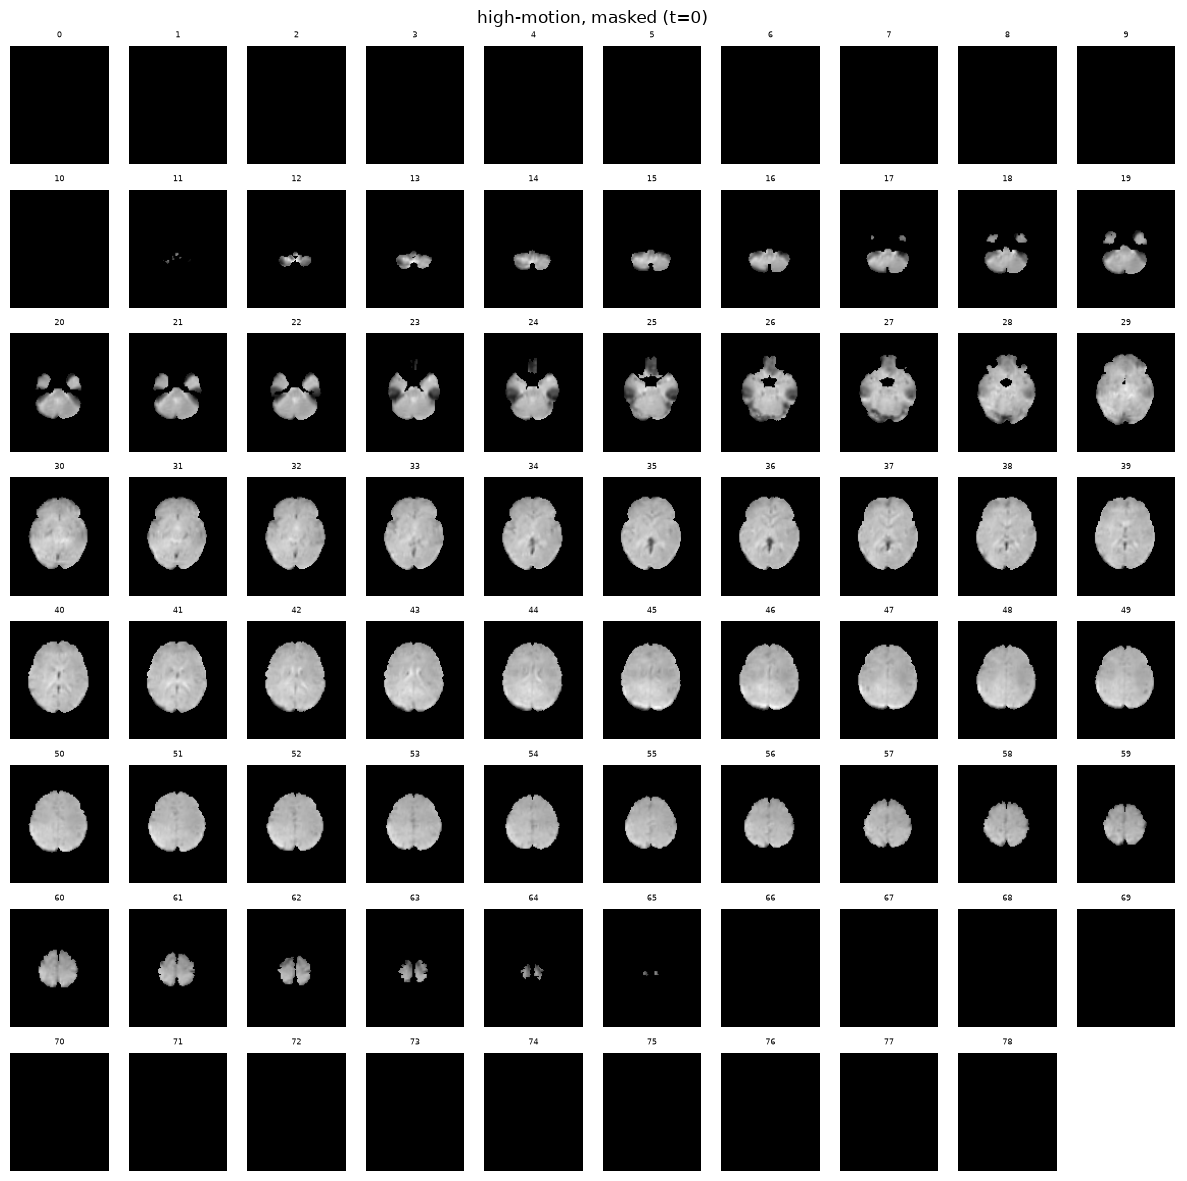

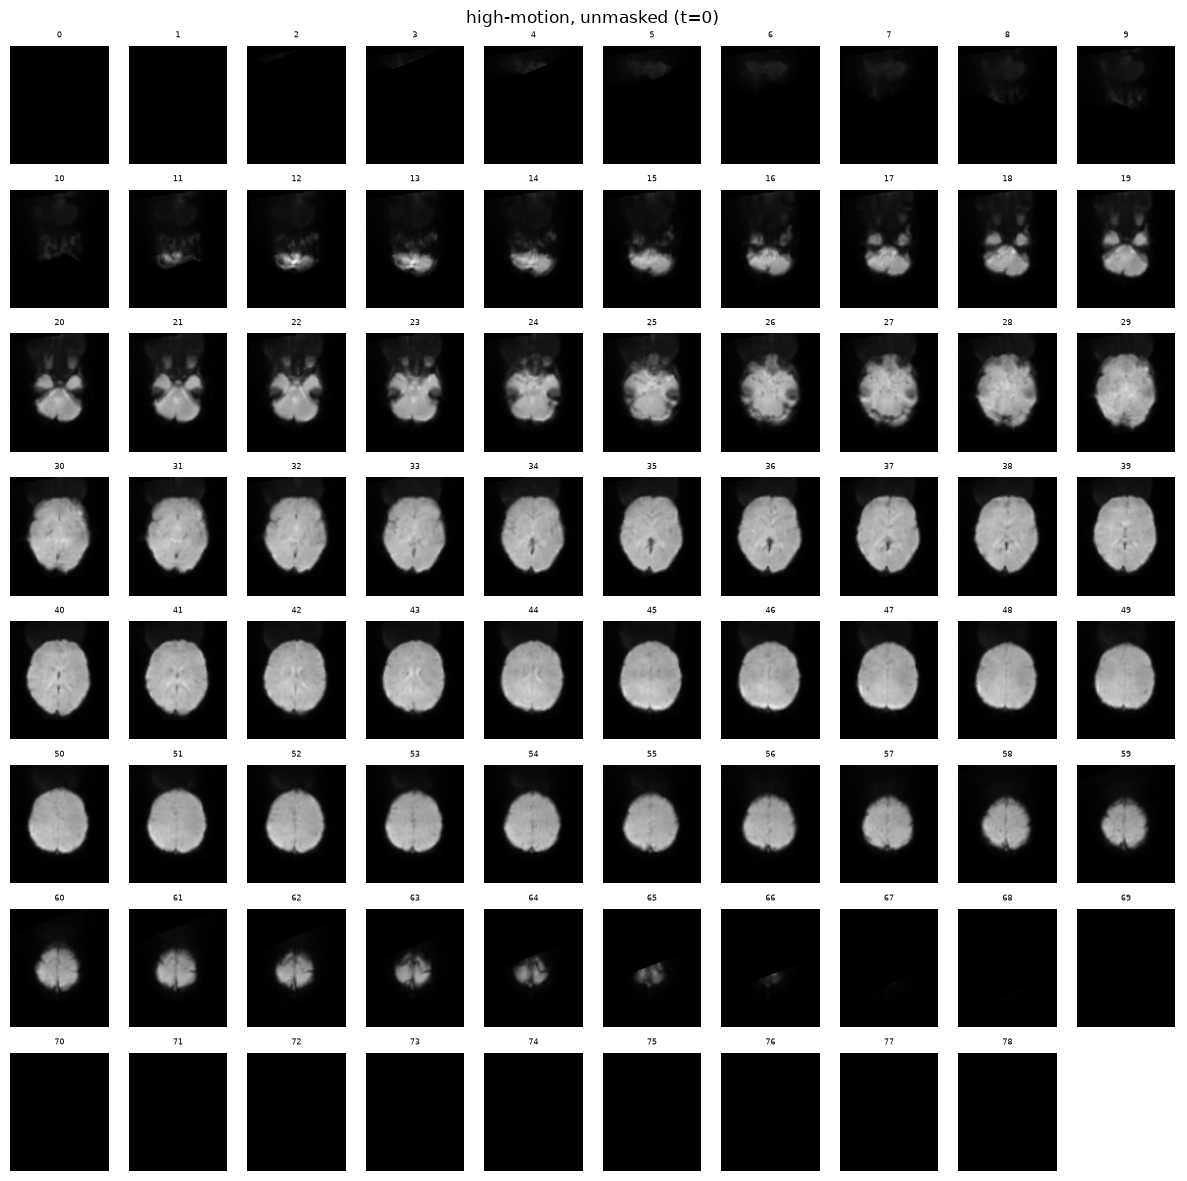

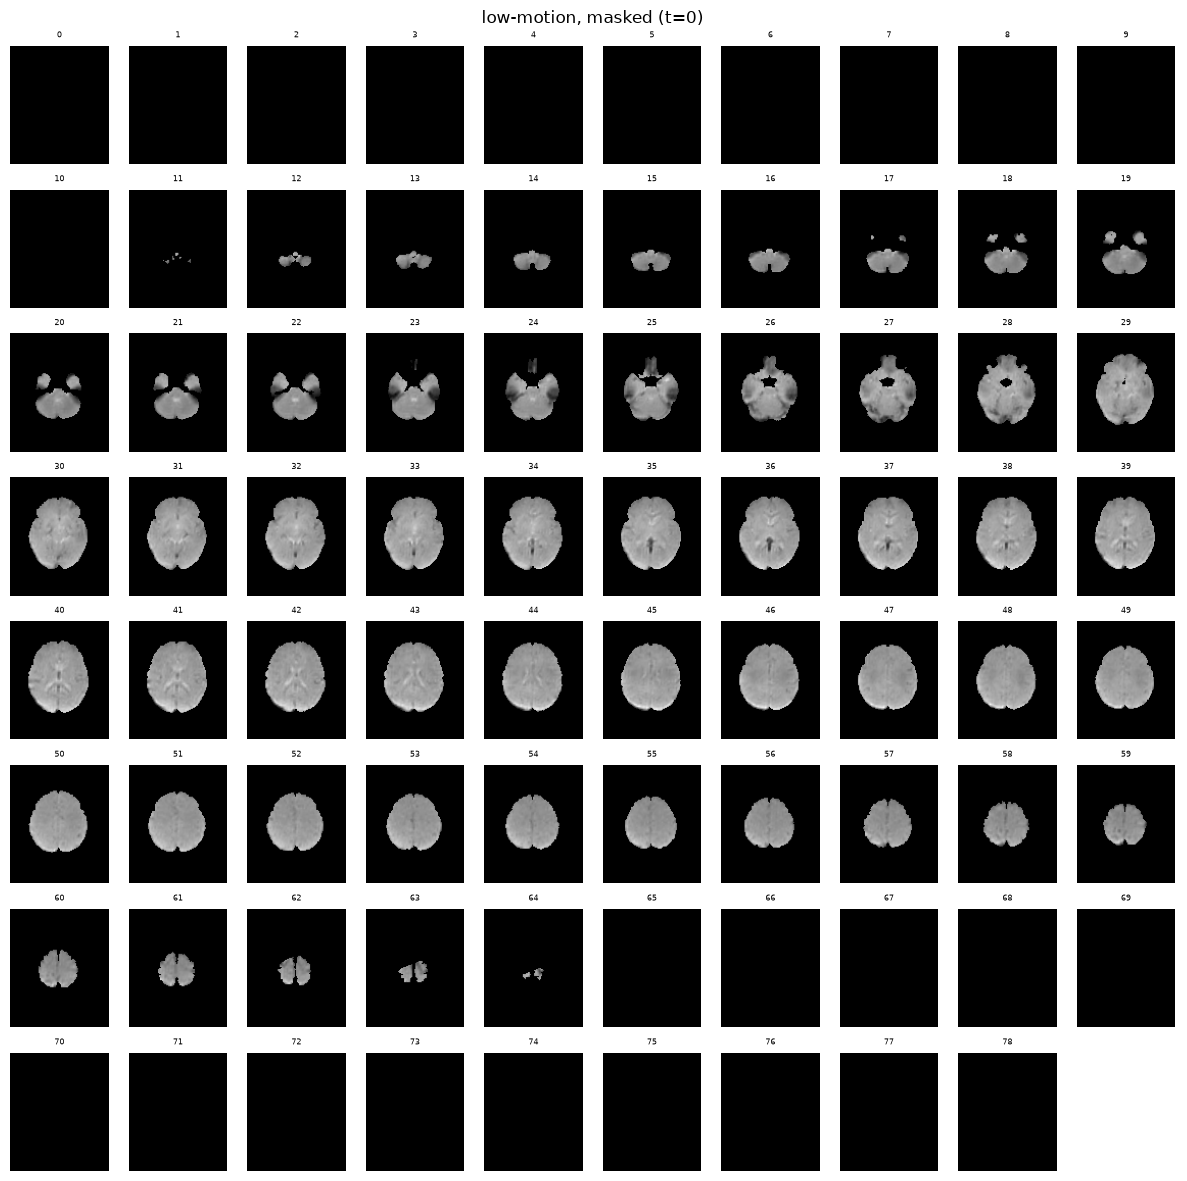

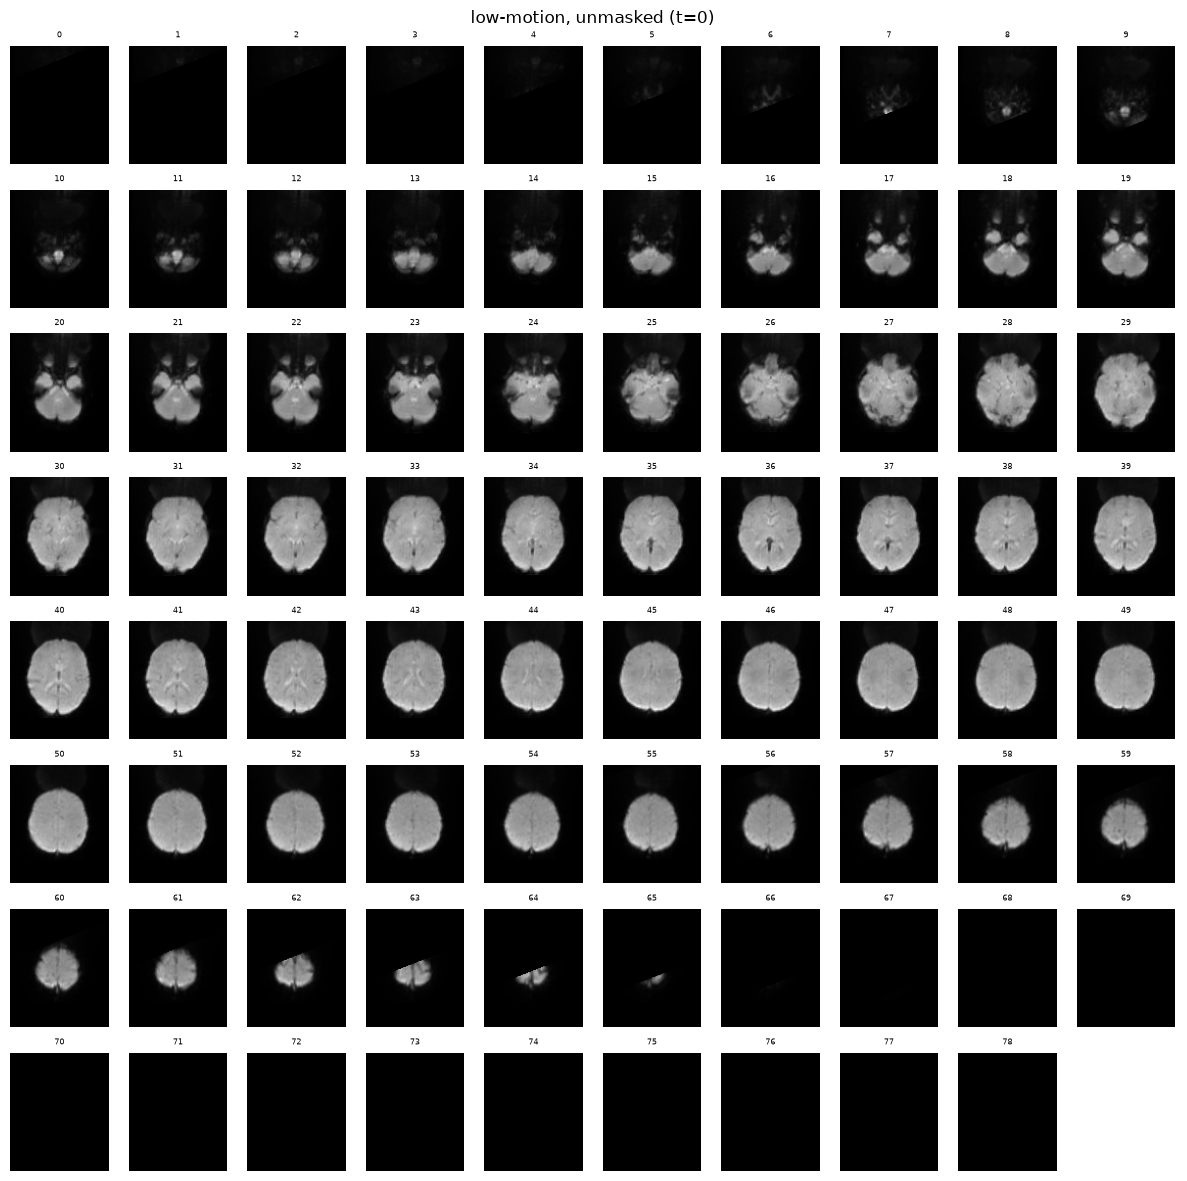

In [4]:
def plot_volume_montage(volume, title, ncols=10, cmap="gray"):
    """volume: 3D array (X, Y, Z). Plots every axial slice in a grid."""
    n_slices = volume.shape[2]
    nrows = int(np.ceil(n_slices / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.2, nrows * 1.5))
    vmax = volume.max()
    for i, ax in enumerate(axes.flat):
        if i < n_slices:
            ax.imshow(volume[:, :, i].T, cmap=cmap, vmin=0, vmax=vmax, origin="lower")
            ax.set_title(str(i), fontsize=6)
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    return fig


plot_volume_montage(data_high_masked[..., 0], "high-motion, masked (t=0)")
plot_volume_montage(data_high_unmasked[..., 0], "high-motion, unmasked (t=0)")
plot_volume_montage(data_low_masked[..., 0], "low-motion, masked (t=0)")
plot_volume_montage(data_low_unmasked[..., 0], "low-motion, unmasked (t=0)")
plt.show()

## Mean projection per timepoint (signal-stability / motion QC over the chunk)

For every timepoint, average the volume along the axial (Z) axis into a single 2D projection, then
lay those projections out left-to-right across time -- for both motion conditions and both
masking states. The low-motion chunk's projections should look nearly identical frame to frame;
the high-motion chunk's should show visible shifting/blurring across timepoints.

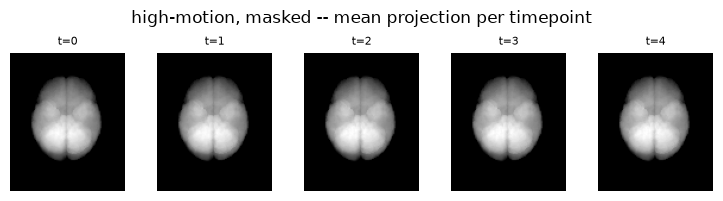

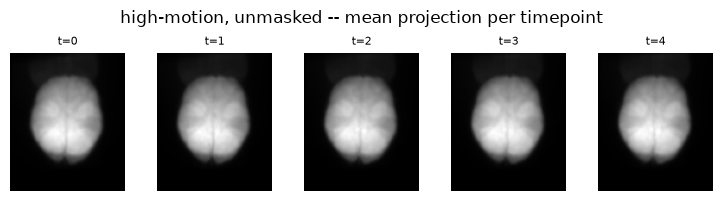

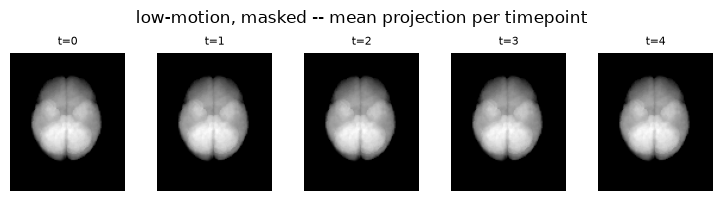

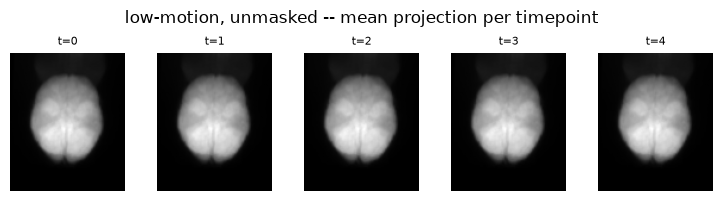

In [5]:
def plot_mean_projection_over_time(data4d, title, axis=2):
    """data4d: 4D array (X, Y, Z, T). Plots the mean intensity projection along `axis`
    for every timepoint, one subplot per timepoint."""
    T = data4d.shape[-1]
    fig, axes = plt.subplots(1, T, figsize=(T * 1.5, 2))
    for t in range(T):
        proj = data4d[..., t].mean(axis=axis)
        ax = axes[t]
        ax.imshow(proj.T, cmap="gray", origin="lower")
        ax.set_title(f"t={t}", fontsize=8)
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    return fig


plot_mean_projection_over_time(data_high_masked, "high-motion, masked -- mean projection per timepoint")
plot_mean_projection_over_time(data_high_unmasked, "high-motion, unmasked -- mean projection per timepoint")
plot_mean_projection_over_time(data_low_masked, "low-motion, masked -- mean projection per timepoint")
plot_mean_projection_over_time(data_low_unmasked, "low-motion, unmasked -- mean projection per timepoint")
plt.show()

## Applying the correct age-appropriate brain mask

Per `templates/readme.md`, the recommended mask for **2-month-old** subjects (this cohort) is
the foundcog-corrected `nihpd_asym_02-05_fcgmask` template mask -- not the plain nihpd-supplied
one (the readme notes that one was poor in the anterior temporal lobes):

```
templates/mask/nihpd_asym_02-05_fcgmask_2mm.nii.gz
```

Its affine matches our data's exactly (verified below), so it can be applied directly with no
extra resampling/registration. This is a **population-level, age-range template mask** -- a
different mask than whatever subject-specific mask FSL actually produced for each individual scan
in the dataset -- so this cell also checks how closely the two agree (Dice overlap) rather than
assuming they're identical.

In [9]:
MASK_PATH = Path("/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/templates/mask/nihpd_asym_02-05_fcgmask_2mm.nii.gz")

mask_img = nib.load(MASK_PATH)
mask = mask_img.get_fdata() > 0  # (X, Y, Z) boolean

assert mask.shape == data_high_unmasked.shape[:3], "mask/data spatial shape mismatch"
assert (mask_img.affine == img_high_unmasked.affine).all(), "mask/data affine mismatch -- would need resampling"


def apply_mask(data4d, mask3d):
    """data4d: (X,Y,Z,T), mask3d: (X,Y,Z) boolean. Zero out everything outside the mask, per timepoint."""
    return data4d * mask3d[..., None]


data_high_fcgmasked = apply_mask(data_high_unmasked, mask)
data_low_fcgmasked = apply_mask(data_low_unmasked, mask)

# Agreement between this template mask and each dataset chunk's own (subject-specific) mask footprint.
for name, dataset_masked in [("high-motion", data_high_masked), ("low-motion", data_low_masked)]:
    own_mask = dataset_masked[..., 0] > 0
    dice = 2 * (own_mask & mask).sum() / (own_mask.sum() + mask.sum())
    print(f"{name}: fcgmask vs dataset's own mask -- Dice overlap = {dice:.3f}")

high-motion: fcgmask vs dataset's own mask -- Dice overlap = 0.960
low-motion: fcgmask vs dataset's own mask -- Dice overlap = 0.960


Stats and a slice montage for the fcgmask-applied volumes, same functions as before.

In [ ]:
print_volume_stats("high-motion, fcgmask-applied", HIGH_MOTION_UNMASKED_PATH, img_high_unmasked, data_high_fcgmasked)
print_volume_stats("low-motion, fcgmask-applied", LOW_MOTION_UNMASKED_PATH, img_low_unmasked, data_low_fcgmasked)

plot_volume_montage(data_high_fcgmasked[..., 0], "high-motion, fcgmask-applied (t=0)")
plot_volume_montage(data_low_fcgmasked[..., 0], "low-motion, fcgmask-applied (t=0)")
plt.show()

## Cropping to the brain bounding box

Slices 0-11 and 66-78 (Z), and large margins on X/Y, are entirely empty per the mask -- cropping
to the mask's bounding box removes them with zero information loss. The box is also padded so
each dimension is divisible by 4, since `ResnetGenerator`'s default downsampling
(`n_downsampling=2`) needs that to reconstruct the exact input shape on the way back up.

crop box (X, Y, Z): [(17, 77), (26, 98), (11, 67)]
shape: (97, 116, 79) -> (60, 72, 56) (all dims divisible by 4: [True, True, True])


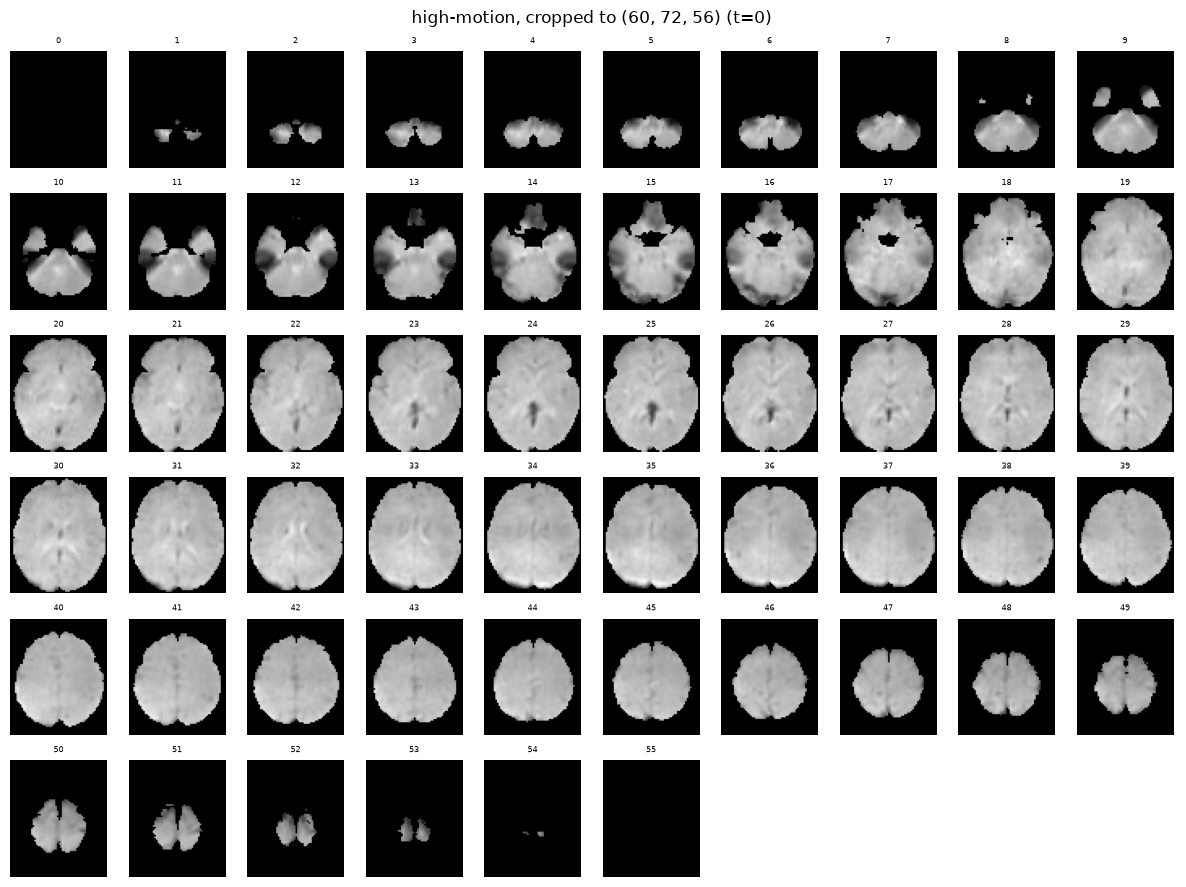

In [11]:
def mask_bbox(mask3d, pad_to_multiple=4):
    """Bounding box of a boolean mask, per axis, expanded so each dimension is divisible by
    `pad_to_multiple`. Returns a tuple of slice objects usable as volume[bbox]."""
    slices = []
    for axis in range(3):
        other = tuple(a for a in range(3) if a != axis)
        nz = np.where(mask3d.any(axis=other))[0]
        lo, hi = int(nz.min()), int(nz.max()) + 1  # hi is exclusive
        pad = (-(hi - lo)) % pad_to_multiple
        lo = max(0, lo - pad // 2)
        hi = min(mask3d.shape[axis], hi + (pad - pad // 2))
        slices.append(slice(lo, hi))
    return tuple(slices)


crop = mask_bbox(mask, pad_to_multiple=4)
cropped_shape = tuple(s.stop - s.start for s in crop)
print(f"crop box (X, Y, Z): {[(s.start, s.stop) for s in crop]}")
print(f"shape: {data_high_fcgmasked.shape[:3]} -> {cropped_shape} (all dims divisible by 4: {[d % 4 == 0 for d in cropped_shape]})")

data_high_cropped = data_high_fcgmasked[crop]
plot_volume_montage(data_high_cropped[..., 0], f"high-motion, cropped to {cropped_shape} (t=0)")
plt.show()

## Does this crop box hold for every chunk, or just this one?

The box above comes from the *template* mask -- one fixed file, same for every subject. But each
dataset chunk was actually masked with its own **subject-specific** mask (recall the Dice overlap
was 0.960, not 1.0), so the template box isn't guaranteed to cover every subject's real brain
content. Check directly against the data: sample chunks across every split and domain, compute each
chunk's own nonzero bounding box (unioned over all timepoints in the chunk, so a voxel counts if it's
nonzero at *any* t), and see whether any of them extend past the template-derived crop box.

In [ ]:
import random


def chunk_nonzero_bbox(data4d):
    """Per-axis (lo, hi) of nonzero voxels in a (X,Y,Z,T) chunk, unioned over T."""
    brain = (data4d != 0).any(axis=-1)
    bbox = []
    for axis in range(3):
        other = tuple(a for a in range(3) if a != axis)
        nz = np.where(brain.any(axis=other))[0]
        bbox.append((int(nz.min()), int(nz.max())) if len(nz) else (None, None))
    return bbox


random.seed(0)
chunk5_root = DATASET_ROOT / "cyclegans_chunk5_dataset"
sampled_files = []
for split in ["train", "val", "test"]:
    for domain in ["A_corrupted", "B_motion_free"]:
        candidates = list((chunk5_root / split / domain).glob("*.nii.gz"))
        sampled_files.extend(random.sample(candidates, min(80, len(candidates))))
print(f"sampling {len(sampled_files)} chunks across all splits/domains...")

observed_lo = [10**9, 10**9, 10**9]
observed_hi = [-1, -1, -1]
for f in sampled_files:
    bbox = chunk_nonzero_bbox(nib.load(f).get_fdata())
    for axis, (lo, hi) in enumerate(bbox):
        if lo is None:
            continue
        observed_lo[axis] = min(observed_lo[axis], lo)
        observed_hi[axis] = max(observed_hi[axis], hi)

for axis, name in enumerate("XYZ"):
    template_lo, template_hi = crop[axis].start, crop[axis].stop - 1
    fits = observed_lo[axis] >= template_lo and observed_hi[axis] <= template_hi
    print(f"{name}: observed across {len(sampled_files)} chunks = {observed_lo[axis]}-{observed_hi[axis]}, "
          f"template-derived crop = {template_lo}-{template_hi} -> fits inside crop: {fits}")

If any axis prints `fits inside crop: False` above, the template-mask crop is clipping real data for
some subjects -- widen `mask_bbox`'s box (or compute it directly from data like this cell does, unioned
across the whole dataset, rather than from the template mask) before using it as a fixed preprocessing
crop for training.

## A better crop box: robust, per-run, cached to CSV

Better strategy than relying on the population template mask: for each **run**, load its full
preprocessed (masked) time series, take the **median volume across time** (robust to any
single-timepoint masking/motion artifact), and derive that run's own bounding box from it. Every
chunk belonging to that run can then reuse the same box -- computed once per run, not once per chunk.

Worth checking rather than assuming: is the mask ever *not* constant across timepoints within a run
(which is the only case where the median actually changes the answer vs. just using one volume)?
Checked directly on both example runs -- the nonzero footprint is **exactly identical across all
485 timepoints** in both. So here the median doesn't correct any real within-run noise; its value is
(a) a cheap defensive default in case some other run's masking isn't perfectly constant, and
(b) using each subject's *own* mask rather than the population template, which we already found
isn't a perfect match (Dice 0.960).

In [ ]:
import pandas as pd


def compute_run_bbox(preprocessed_bold_file, pad_to_multiple=4):
    """Load a full preprocessed (masked) run, take the median volume across time, and return its
    nonzero bounding box as a dict, padded so each dimension is divisible by `pad_to_multiple`."""
    img = nib.load(preprocessed_bold_file)
    data = img.get_fdata()
    median_vol = np.median(data, axis=-1)
    mask3d = median_vol > 0

    bbox = {}
    for axis, name in enumerate("xyz"):
        other = tuple(a for a in range(3) if a != axis)
        nz = np.where(mask3d.any(axis=other))[0]
        lo, hi = int(nz.min()), int(nz.max()) + 1
        pad = (-(hi - lo)) % pad_to_multiple
        lo = max(0, lo - pad // 2)
        hi = min(mask3d.shape[axis], hi + (pad - pad // 2))
        bbox[f"{name}_lo"], bbox[f"{name}_hi"] = lo, hi
    bbox["n_volumes"] = data.shape[-1]
    return bbox


# Demo on the two example runs already in use above (same subject, two different `videos` runs).
PREPROC_ROOT = DERIVATIVES_ROOT / "normalized_to_common_space_cycleGANS_preprocessed_data"
example_runs = [
    dict(subject_id="ICC103A", session_id=1, run_id=1, task="videos",
         preprocessed_bold_file=PREPROC_ROOT / "_subject_id_ICC103A/_referencetype_standard/_run_001_session_1_task_name_videos/sub-ICC103A_ses-1_task-videos_dir-AP_run-001_bold_mcf_corrected_flirt_masked.nii.gz"),
    dict(subject_id="ICC103A", session_id=1, run_id=2, task="videos",
         preprocessed_bold_file=PREPROC_ROOT / "_subject_id_ICC103A/_referencetype_standard/_run_002_session_1_task_name_videos/sub-ICC103A_ses-1_task-videos_dir-AP_run-002_bold_mcf_corrected_flirt_masked.nii.gz"),
]

run_bbox_rows = [{**run, **compute_run_bbox(run["preprocessed_bold_file"])} for run in example_runs]
run_bbox_df = pd.DataFrame(run_bbox_rows)
run_bbox_df

Save to CSV so the (expensive: ~18s per run, full time series) computation only ever has to run
once per run, not once per chunk or once per training epoch.

In [ ]:
RUN_BBOX_CSV_PATH = Path("run_bounding_boxes.csv")
run_bbox_df.to_csv(RUN_BBOX_CSV_PATH, index=False)
print(f"saved {len(run_bbox_df)} run(s) to {RUN_BBOX_CSV_PATH.resolve()}")

## Combining across runs into one uniform crop size

For batching in training, every chunk needs to end up the same spatial shape regardless of which
run it came from. Take the **union** of every run's box (not an average) -- the smallest box that
still contains every run's own brain content -- then pad to a multiple of 4. Union guarantees zero
clipping for any included run, unlike the earlier template-mask box, which we found *did* clip a few
voxels for some subjects.

Caveat on the demo below: both example runs are the *same subject*, so they trivially agree (same
individual's own mask). That doesn't yet test the real question -- how much the box varies **across
different subjects**. Answering that for real means running `compute_run_bbox` over every unique run
in the dataset (one row per unique `preprocessed_bold_file` across `metadata/*.csv`), which is a
genuine batch job at ~18s/run over hundreds of runs -- worth running as a standalone script rather
than inline here, then loading its output CSV in this notebook for analysis.

In [ ]:
union_box = {f"{axis}_lo": int(run_bbox_df[f"{axis}_lo"].min()) for axis in "xyz"}
union_box.update({f"{axis}_hi": int(run_bbox_df[f"{axis}_hi"].max()) for axis in "xyz"})
union_shape = tuple(union_box[f"{a}_hi"] - union_box[f"{a}_lo"] for a in "xyz")

print(f"union box across {len(run_bbox_df)} run(s): {union_box}")
print(f"uniform crop/pad shape for training: {union_shape} (divisible by 4: {[d % 4 == 0 for d in union_shape]})")

## Run-level pipeline: mask -> crop -> robust normalize -> verify denormalization

Full pipeline for one run, in the order it would actually be applied before training:

1. Load the **raw run in common space** (unmasked, full time series -- not a chunk slice).
2. Apply the age-appropriate **fcgmask** from `templates/mask/` (not a subject-specific mask).
3. Take the **median volume** across time and derive the bounding box from it (reusing `mask_bbox`
   from earlier), then crop to that box.
4. **Robustly normalize**, using only brain-mask voxel statistics (median-centered, scaled by the
   5th-95th percentile range -- robust to the small number of very bright/dark outlier voxels that
   would distort a plain mean/std normalization).
5. **Denormalize** and check the reconstruction error, to confirm the transform is safely invertible.

In [12]:
RAW_RUN_PATH = HIGH_MOTION_UNMASKED_PATH  # same file used earlier, now loaded as the FULL run (no chunk slice)

raw_run_img = nib.load(RAW_RUN_PATH)
raw_run = raw_run_img.get_fdata()  # (X, Y, Z, T), unmasked, common space
print(f"raw run shape: {raw_run.shape}")

masked_run = raw_run * mask[..., None]  # `mask` = the fcgmask loaded earlier

median_vol = np.median(masked_run, axis=-1)  # (X, Y, Z)
brain_mask_3d = median_vol > 0
print(f"median-volume brain footprint matches fcgmask exactly: {np.array_equal(brain_mask_3d, mask)}")

run_crop = mask_bbox(brain_mask_3d, pad_to_multiple=4)  # reuses the function defined earlier
cropped_shape = tuple(s.stop - s.start for s in run_crop)
print(f"crop box: {[(s.start, s.stop) for s in run_crop]} -> shape {cropped_shape}")

cropped_fmri = masked_run[run_crop]  # (x, y, z_cropped, T)
cropped_mask = mask[run_crop]  # (x, y, z_cropped) boolean, same crop applied to the mask itself
print(f"cropped_fmri shape: {cropped_fmri.shape}")

raw run shape: (97, 116, 79, 485)
median-volume brain footprint matches fcgmask exactly: True
crop box: [(17, 77), (26, 98), (11, 67)] -> shape (60, 72, 56)
cropped_fmri shape: (60, 72, 56, 485)


Robust run-level normalization: center on the brain voxels' median, scale by their **MAD**
(median absolute deviation, x 1.4826 so it approximates a standard deviation under a
near-Gaussian assumption) -- a more standard robust scale estimator than the p5-p95 range used in
an earlier version of this cell. Only brain-mask voxels are transformed; background stays
**exactly 0** (not a nonzero constant), so background is consistent across every run rather than
drifting with each run's own median/scale.

In [15]:
def robust_normalize(fmri, brain_mask):
    """Median/MAD-style run-level normalization using only brain-mask voxel statistics.
    Background (outside brain_mask) is left at exactly 0, not transformed -- so background is a
    fixed, dataset-wide constant rather than a different value per run.
    Returns (fmri_normalized, median, scale). Denormalize brain voxels via
    fmri_normalized[brain_mask] * scale + median (background is not reconstructible this way,
    since it was never transformed in the first place -- it's already correct as 0)."""
    x_brain = fmri[brain_mask]  # (n_brain_voxels, T)
    median = np.median(x_brain)
    mad = np.median(np.abs(x_brain - median))
    scale = max(1.4826 * mad, 1e-8)

    fmri_normalized = np.zeros_like(fmri, dtype=np.float32)
    fmri_normalized[brain_mask] = (fmri[brain_mask] - median) / scale
    return fmri_normalized, median, scale


fmri_normalized, run_median, run_scale = robust_normalize(cropped_fmri, cropped_mask)

# For comparison: the old p5-p95 range scale estimator, on the same brain voxels.
x_brain = cropped_fmri[cropped_mask]
p5, p95 = np.percentile(x_brain, [5, 95])
old_scale = max(p95 - p5, 1e-8)

print(f"median = {run_median:.3f}")
print(f"MAD-based scale (1.4826 * MAD) = {run_scale:.3f}")
print(f"old p5-p95 range scale         = {old_scale:.3f}")
print(f"normalized brain-voxel range: [{fmri_normalized[cropped_mask].min():.3f}, {fmri_normalized[cropped_mask].max():.3f}]")
# print(f"background value (voxels outside mask): {fmri_normalized[~cropped_mask][0]:.4f}  (should be exactly 0.0)")
print(f"background is exactly zero everywhere: {np.array_equal(fmri_normalized[~cropped_mask], np.zeros_like(fmri_normalized[~cropped_mask]))}")

median = 348.071
MAD-based scale (1.4826 * MAD) = 33.016
old p5-p95 range scale         = 139.812
normalized brain-voxel range: [-10.204, 7.420]
background is exactly zero everywhere: True


In [ ]:
fmri_denormalized = np.zeros_like(cropped_fmri, dtype=np.float32)
fmri_denormalized[cropped_mask] = fmri_normalized[cropped_mask] * run_scale + run_median
# background wasn't transformed, so it's already correct at 0 -- no denorm step needed for it

abs_err_brain = np.abs(fmri_denormalized[cropped_mask] - cropped_fmri[cropped_mask])
print(f"round-trip max abs error (brain voxels): {abs_err_brain.max():.3e}")
print(f"round-trip mean abs error (brain voxels): {abs_err_brain.mean():.3e}")
print(f"background exactly preserved (0 == 0): {np.array_equal(fmri_denormalized[~cropped_mask], cropped_fmri[~cropped_mask])}")
print(f"denormalization exact to floating-point precision (brain voxels): {np.allclose(fmri_denormalized[cropped_mask], cropped_fmri[cropped_mask])}")

**Important finding**: switching from p5-p95 range to MAD as the scale estimator changes the
normalized range a lot, not just a little. On this example run: MAD-based scale = 33.0 vs. the old
p5-p95 scale = 139.8 -- roughly 4x smaller. That's expected (p5-p95 spans ~90% of a distribution,
~3.3 std for a Gaussian, while `1.4826*MAD` approximates exactly 1 std), but the practical
consequence is real: the MAD-normalized brain-voxel range came out around **`[-10.2, 7.4]`**
(vs. roughly `[-2.4, 1.8]` with the old p5-p95 scale), and **~32% of brain voxels at a single
timepoint fall outside `[-1, 1]`** and would get clipped -- far more than before.

This isn't a bug -- it's the MAD version correctly reporting that fMRI brain-voxel intensity is
substantially heavy-tailed/skewed (bright vessels, CSF, partial-volume edge effects), which
p5-p95's wider scale was quietly compressing. It does mean simply clipping to `[-1, 1]` throws away
a much bigger chunk of real signal than before -- worth deciding deliberately (wider clip bounds,
a softer squashing function, or clipping in raw-intensity percentile space before normalizing)
rather than reusing the old `[-1, 1]` clip unchanged.

## Cropped volume, all three orientations

Same slice-montage treatment as the earlier axial (XY) view, now for all three planes of the
**cropped** volume (`cropped_fmri` from the run-level pipeline above): axial (XY, iterating over Z),
coronal (XZ, iterating over Y), and sagittal (YZ, iterating over X). Confirms the crop looks correct
from every direction, not just the one already shown.

In [ ]:
def plot_montage_along_axis(volume, axis, title, ncols=10, cmap="gray", vmin=0, vmax=None,
                             overlay=None, overlay_cmap="nipy_spectral", overlay_alpha=0.5):
    """volume: 3D array. Plots every slice along `axis` in a grid
    (axis=0: sagittal/YZ, axis=1: coronal/XZ, axis=2: axial/XY). vmax=None auto-scales to
    volume.max() (the original behavior); pass explicit vmin/vmax to display a fixed scale
    (e.g. 0/1 for already-normalized data). If `overlay` is given (3D array, same shape as
    volume), it's alpha-blended on top of every slice, with value 0 treated as background
    (transparent) -- e.g. for an atlas/parcellation overlay."""
    n_slices = volume.shape[axis]
    nrows = int(np.ceil(n_slices / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.2, nrows * 1.5))
    vmax = volume.max() if vmax is None else vmax
    for i, ax in enumerate(axes.flat):
        if i < n_slices:
            sl = np.take(volume, i, axis=axis)
            ax.imshow(sl.T, cmap=cmap, vmin=vmin, vmax=vmax, origin="lower")
            if overlay is not None:
                ov_sl = np.take(overlay, i, axis=axis)
                ov_masked = np.ma.masked_where(ov_sl == 0, ov_sl)
                ax.imshow(ov_masked.T, cmap=overlay_cmap, alpha=overlay_alpha, origin="lower")
            ax.set_title(str(i), fontsize=6)
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    return fig


cropped_t0 = cropped_fmri[..., 0]
plot_montage_along_axis(cropped_t0, axis=2, title=f"cropped axial (XY) slices, shape {cropped_t0.shape}")
plot_montage_along_axis(cropped_t0, axis=1, title=f"cropped coronal (XZ) slices, shape {cropped_t0.shape}")
plot_montage_along_axis(cropped_t0, axis=0, title=f"cropped sagittal (YZ) slices, shape {cropped_t0.shape}")
plt.show()

## Min-max normalized to the run's own intensity range

Same cropped axial view, but intensity-normalized using the **whole run's** brain-voxel min/max
(all timepoints, via `cropped_mask`) rather than this single timepoint's own range -- so the display
scale is consistent with what the rest of the run looks like, not re-stretched per frame.

In [ ]:
run_min = cropped_fmri[cropped_mask].min()
run_max = cropped_fmri[cropped_mask].max()
print(f"run-level intensity range (brain voxels, all {cropped_fmri.shape[-1]} timepoints): min={run_min:.2f}, max={run_max:.2f}")

cropped_t0_minmax = (cropped_t0 - run_min) / (run_max - run_min)
print(f"t=0 normalized brain-voxel range: [{cropped_t0_minmax[cropped_mask].min():.3f}, {cropped_t0_minmax[cropped_mask].max():.3f}]")

plot_montage_along_axis(
    cropped_t0_minmax, axis=2,
    title=f"cropped axial (XY), min-max normalized to run [{run_min:.1f}, {run_max:.1f}], shape {cropped_t0_minmax.shape}",
    vmin=0, vmax=1,
)
plt.show()

## Robust-normalized (median/MAD), clipped to [-1, 1]

Same cropped axial view, using the **robust** (median/MAD) normalization from `robust_normalize()`
above (`fmri_normalized`, already computed run-level, all timepoints) instead of min-max. Unlike
min-max, a motion-induced intensity spike at one timepoint can't distort the scale for the rest of
the run, since the median/MAD statistics barely move for a handful of outlier voxels.

The tradeoff, now more visible than with the old p5-p95 version: robust normalization doesn't
itself guarantee a bounded range, and MAD's tighter scale means a much larger fraction of brain
voxels land outside `[-1, 1]` (see the note above -- roughly a third at a single timepoint here) --
so clipping here is discarding real signal, not just rare extreme outliers. Shown anyway for
comparison, but this is the point where a wider clip range or a different squashing approach is
worth considering before this feeds an actual `Tanh`-bounded generator.

In [6]:
robust_clipped_t0 = np.clip(fmri_normalized[..., 0], -1, 1)

unclipped_range = fmri_normalized[..., 0][cropped_mask]
frac_clipped = ((unclipped_range < -1) | (unclipped_range > 1)).mean()
print(f"before clip, t=0 brain-voxel range: [{unclipped_range.min():.3f}, {unclipped_range.max():.3f}]")
print(f"after clip, t=0 brain-voxel range: [{robust_clipped_t0[cropped_mask].min():.3f}, {robust_clipped_t0[cropped_mask].max():.3f}]")
print(f"fraction of brain voxels clipped: {frac_clipped:.3%}")

plot_montage_along_axis(
    robust_clipped_t0, axis=2,
    title=f"cropped axial (XY), robust-normalized (median={run_median:.1f}, scale={run_scale:.1f}) + clipped to [-1,1], shape {robust_clipped_t0.shape}",
    vmin=-1, vmax=1,
)
plt.show()

NameError: name 'fmri_normalized' is not defined

## Schaefer 400-parcel atlas overlay

Age-appropriate atlas selection, per `templates/readme.md`'s subject-naming convention: a subject
ID **ending in `A`** is the **9-month-old** cohort (`nihpd-08-11` space); everyone else is
**2-month-old** (`nihpd-02-05` space) -- the same convention behind the fcgmask naming used earlier.

**Note:** our example subject is `ICC103A`, which *ends in `A`* -- so by this rule it's actually
**9-month-old**, not 2-month-old. Every earlier cell in this notebook (mask, bounding box,
normalization) used the **2mo** fcgmask for this same subject. That's a real inconsistency this
cell surfaces rather than quietly repeats -- worth revisiting the earlier cells with the correct
age-appropriate mask if this naming rule is right.

In [ ]:
import re

ATLAS_ROOT = Path("/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/templates/rois")
ATLAS_PATHS = {
    "2mo": ATLAS_ROOT / "Schaefer2018_400Parcels_7Networks_order_space-nihpd-02-05_2mm.nii.gz",
    "9mo": ATLAS_ROOT / "Schaefer2018_400Parcels_7Networks_order_space-nihpd-08-11_2mm.nii.gz",
}

subject_id = re.search(r"_subject_id_(\w+)", str(RAW_RUN_PATH)).group(1)
age_group = "9mo" if subject_id.endswith("A") else "2mo"
print(f"subject_id={subject_id} -> age_group={age_group} -> atlas={ATLAS_PATHS[age_group].name}")

atlas_img = nib.load(ATLAS_PATHS[age_group])
atlas = atlas_img.get_fdata()
assert atlas.shape == mask.shape, f"atlas shape {atlas.shape} != data shape {mask.shape}"
assert np.array_equal(atlas_img.affine, mask_img.affine), "atlas and mask are not in the same space"

cropped_atlas = atlas[run_crop]  # same bounding box used for the fMRI data throughout
print(f"cropped atlas shape: {cropped_atlas.shape}, parcels present in crop: {len(np.unique(cropped_atlas)) - 1} / 400")

In [ ]:
plot_montage_along_axis(
    cropped_t0, axis=2,
    title=f"cropped axial (XY) with Schaefer 400-parcel ({age_group}) overlay, subject {subject_id}, shape {cropped_t0.shape}",
    overlay=cropped_atlas,
)
plt.show()

## QA: spot-check the built `brain_masked_cropped_2mo` dataset

Pick one random `videos` run and one random `rest10` run from the SLURM-built output dataset
(job 16510, 432/432 ok), check their stats, and plot them -- confirms the batch job actually
produced correct, uniformly-shaped, properly-masked data, not just that it didn't crash.

In [ ]:
import random

OUT_DATASET_ROOT = Path("/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/faizan_motion_correction_dataset/brain_masked_cropped_normalized_to_common_space")

random.seed(1)
qa_videos_files = list(OUT_DATASET_ROOT.glob("_subject_id_*/_referencetype_standard/_run_*_session_*_task_name_videos/*.nii.gz"))
qa_rest_files = list(OUT_DATASET_ROOT.glob("_subject_id_*/_referencetype_standard/_run_*_session_*_task_name_rest10/*.nii.gz"))
print(f"videos files: {len(qa_videos_files)}, rest10 files: {len(qa_rest_files)}")

qa_videos_path = random.choice(qa_videos_files)
qa_rest_path = random.choice(qa_rest_files)
print(f"QA videos run: {qa_videos_path.name}")
print(f"QA rest10 run: {qa_rest_path.name}")

img_qa_videos = nib.load(qa_videos_path)
data_qa_videos = img_qa_videos.get_fdata(dtype=np.float32)
img_qa_rest = nib.load(qa_rest_path)
data_qa_rest = img_qa_rest.get_fdata(dtype=np.float32)

print_volume_stats("QA videos (cropped+masked)", qa_videos_path, img_qa_videos, data_qa_videos)
print_volume_stats("QA rest10 (cropped+masked)", qa_rest_path, img_qa_rest, data_qa_rest)

Verify the things the build job was supposed to guarantee: uniform `(60,72,56)` spatial shape,
`float32` storage, and correct source metadata (TR) carried through -- this last one caught a real
bug: the first version of `build_dataset.py` built a fresh `Nifti1Image` without the source header,
so TR silently defaulted to nibabel's generic `1.0s` instead of the source's actual `0.61s`. Fixed
in the script (now copies the source header and only updates shape/dtype/affine); the dataset on
disk will need rebuilding to pick that fix up.

In [1]:
for name, path, img, data in [("videos", qa_videos_path, img_qa_videos, data_qa_videos), ("rest10", qa_rest_path, img_qa_rest, data_qa_rest)]:
    assert data.shape[:3] == (60, 72, 56), f"{name}: unexpected spatial shape {data.shape[:3]}"
    assert data.dtype == np.float32, f"{name}: unexpected dtype {data.dtype}"
    tr = img.header.get_zooms()[3]
    print(f"{name}: shape {data.shape[:3]} OK, dtype {data.dtype} OK, TR={tr:.2f}s")

NameError: name 'qa_videos_path' is not defined

In [ ]:
plot_montage_along_axis(data_qa_videos[..., 0], axis=2, title=f"QA videos t=0, {qa_videos_path.parts[-4]}, shape {data_qa_videos.shape[:3]}")
plot_montage_along_axis(data_qa_rest[..., 0], axis=2, title=f"QA rest10 t=0, {qa_rest_path.parts[-4]}, shape {data_qa_rest.shape[:3]}")
plt.show()